Running simulation for eps=0.0
--> TEMPO computation:
100.0%   50 of   50 [########################################] 00:00:33
Elapsed time: 33.5s
Running simulation for eps=1.0
--> TEMPO computation:
100.0%   50 of   50 [########################################] 00:00:35
Elapsed time: 35.1s
Running simulation for eps=2.0
--> TEMPO computation:
100.0%   50 of   50 [########################################] 00:01:04
Elapsed time: 64.8s


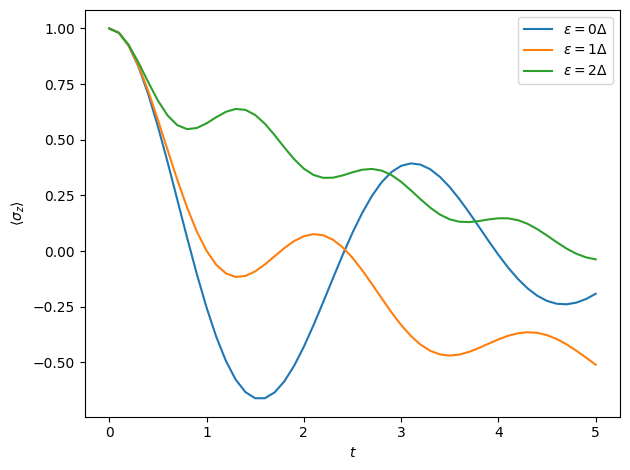

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import oqupy
from oqupy import bath_correlations as bc
import os
import json

# =========================================================
# Parameters
# =========================================================
Delta = 1.0
beta = 5.0 / Delta
dt = 0.1
t_end = 5.0 / Delta

omega_c = 2.5 * Delta
xi = 0.2
L = 200
omega_max = 4.0 * omega_c

eps_list = [0.0, 1.0 * Delta, 2.0 * Delta]

results_dir = "results_spinboson"
os.makedirs(results_dir, exist_ok=True)

# =========================================================
# Discrete bath
# =========================================================
def make_discrete_bath(omega_c, omega_max, xi, L):
    l = np.arange(1, L + 1, dtype=float)
    fac = (1.0 - np.exp(-omega_max / omega_c))
    omega_l = omega_c * np.log(1.0 / (1.0 - (l / L) * fac))
    c_l = omega_l * np.sqrt(xi * omega_c / (L * fac))
    return omega_l, c_l

omega_l, c_l = make_discrete_bath(omega_c, omega_max, xi, L)

def coth(x):
    x = np.asarray(x)
    small = np.abs(x) < 1e-8
    out = np.empty_like(x)
    out[small] = 1.0/x[small] + x[small]/3.0
    out[~small] = np.cosh(x[~small]) / np.sinh(x[~small])
    return out

pref = (c_l**2) / (2.0 * omega_l)
therm = coth(0.5 * beta * omega_l)

def C_tau(tau):
    tau = np.asarray(tau)
    sign = np.sign(tau)
    tau_abs = np.abs(tau)

    wt = np.outer(omega_l, tau_abs)
    val = np.sum(
        pref[:, None] * (therm[:, None] * np.cos(wt) - 1j * np.sin(wt)),
        axis=0
    )
    val = np.where(sign < 0, np.conj(val), val)
    return val.item() if val.shape == () else val

correlations = bc.CustomCorrelations(correlation_function=C_tau)

# =========================================================
# System
# =========================================================
sigma_x = oqupy.operators.sigma("x")
sigma_z = oqupy.operators.sigma("z")
rho0 = oqupy.operators.spin_dm("z+")

coupling_op = sigma_z
bath = oqupy.Bath(coupling_op, correlations)

tcut = 6.0
dkmax = int(np.ceil(tcut / dt))

tempo_params = oqupy.TempoParameters(dt=dt, dkmax=dkmax, epsrel=1e-7)

# =========================================================
# Run + Save
# =========================================================
plt.figure()

for eps in eps_list:

    filename = os.path.join(
        results_dir,
        f"eps_{eps}_dt{dt:.2f}.npz"
    )

    if os.path.exists(filename):
        print(f"Loading existing result: {filename}")
        data = np.load(filename)
        t = data["t"]
        sz = data["sz"]
    else:
        print(f"Running simulation for eps={eps}")

        Hs = eps * sigma_z + Delta * sigma_x
        system = oqupy.System(Hs)

        dynamics = oqupy.tempo_compute(
            system=system,
            bath=bath,
            initial_state=rho0,
            start_time=0.0,
            end_time=t_end,
            parameters=tempo_params,
            unique=False,
        )

        t, sz = dynamics.expectations(sigma_z, real=True)

        # Save arrays
        np.savez(filename, t=t, sz=sz)

        # Save metadata (JSON)
        meta = {
            "Delta": Delta,
            "beta": beta,
            "omega_c": omega_c,
            "xi": xi,
            "L": L,
            "omega_max": omega_max,
            "dt": dt,
            "dkmax": dkmax,
            "eps": eps
        }
        with open(filename.replace(".npz", ".json"), "w") as f:
            json.dump(meta, f, indent=4)

    plt.plot(t, sz, label=fr"$\epsilon={eps/Delta:.0f}\Delta$")

plt.xlabel(r"$t$")
plt.ylabel(r"$\langle\sigma_z\rangle$")
plt.legend()
plt.tight_layout()
plt.show()